# Voice under Stress - Analysis

import of all functions needed

In [1]:
import os
import sys

#from __future__ import division
import pandas as pd
import datetime as dt
import imageio
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import scipy 
#import librosa
import math
from statsmodels.stats.descriptivestats import sign_test

from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, auc, precision_recall_curve, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, LeaveOneOut, StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn import metrics, svm, linear_model
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler
from xgboost import XGBRegressor

from scipy import stats
from scipy.stats import skew, kurtosis
from statsmodels.stats.descriptivestats import sign_test

from matplotlib import rcParams

In [ ]:
homepath=os.getcwd()
scripts_path=os.path.join(homepath, 'scripts')
sys.path.append(scripts_path)

import importlib
import myml
import mystress
import myvoice

importlib.reload(myvoice)
importlib.reload(mystress)
importlib.reload(myml)

In [ ]:

# Check version of Python==64
!python -c "import sys; print(sys.maxsize > 2**32)"

# random seed for reproducability
np.random.seed(42)

# show all columns of dataframes
pd.set_option('display.max_columns', None)

# set current dir to highest hierachy to add data path
os.chdir('/')
data_folder='/data'


sys.path.append(data_folder)
os.chdir(homepath)


True


In [ ]:
filename_librosa='./processed_nemo_data/features.csv'
filename_behavior=data_folder + '/raw/TSST_behavior.csv'
filename_praat='./processed_nemo_data/new_praat_results'
filename_opensmile='./processed_nemo_data/opensmile_features.csv'
filename_output='./processed_nemo_data/df_vpn'

df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)
df=mystress.calc_var(df)

In [5]:
pd.set_option('display.max_columns', None)

# Main Code

### Step 1: load data and calculate variables

In [ ]:
df, librosa_featurenames, praat_featurenames, opensimle_feature=mystress.load_df(filename_opensmile, filename_praat, 
                                                 filename_librosa, filename_behavior, filename_output)
df=mystress.calc_var(df)

# In this Notebook the Training will only be on the TSST condition data

In [7]:
df_TSST = df[df["Cond"] == 1]

In [8]:
len(opensimle_feature)

88

In [9]:
audio=praat_featurenames +librosa_featurenames[0:40]+list(opensimle_feature)
audio.append('Sex')

In [10]:
small_audio=['meanF0Hz', 'stdevF0Hz', 'HNR', 'localJitter', 'localShimmer', 'energy', 'Sex']

In [ ]:
#update nachänderung
import importlib
import myvoice
import myml

importlib.reload(myvoice)
importlib.reload(mystress)
importlib.reload(myml)

# Regression

## Random Forest Regressor

### with hyperparameter tuning (max_depth)

Here we are using a LOO (Leave One Out) for regression with a nested 5-fold CV for hyperparameter tuning (GridSearchCV).
In each iteraton the model is tuned on the training data and then predicts the hold out sample. Performance is compared to a mean-baseline and repeated for all folds.

This is done to predict Cortisol_React, cort_20_min, sAA_React, PANA_Delta_NA, PANA_Delta_PA

In [12]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'Cortisol_React')

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_tsst_cortisol_react",
    space=space,
    scaling="yes",
    features=audio
)


Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. F1bandwidth_sma3nz_amean   0.113671 ±   0.040265
 2. spectrum_33            0.108021 ±   0.041967
 3. spectrum_11            0.043753 ±   0.021757
 4. spectrum_3             0.041249 ±   0.017892
 5. spectrum_36            0.033455 ±   0.014296



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 118.0 pvalue: 0.24106645584106445


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
6.51415414747447
Mean_Absolute_Error:
4.927355083532628
Standard Deviation of the Error:
4.260912594485367
Spearman Correlation:
Spearman r: 0.27184412 (p=0.18866059)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.704226466988215
Mean_Absolute_Error:
5.549382187866667
Standard Deviation of the abs Error:
3.7617828025622964
Saved CSV: RF_tsst_cortisol_react_loo_abs_error.csv


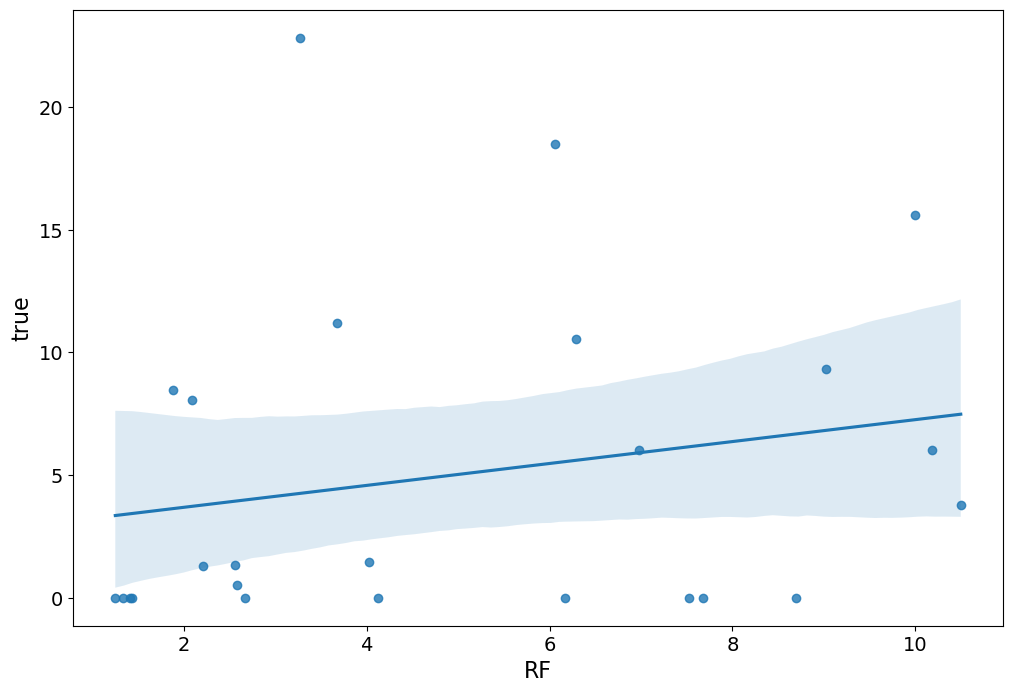

In [13]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [13]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'cort_20_min') 

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_cort_20_min",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_3             0.172396 ±   0.051150
 2. spectrum_18            0.043462 ±   0.017971
 3. spectrum_11            0.041891 ±   0.020128
 4. spectrum_39            0.041469 ±   0.019373
 5. spectrum_36            0.039278 ±   0.017609



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 138.0 pvalue: 0.5249125957489014


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
6.943674281802132
Mean_Absolute_Error:
5.805946007420566
Standard Deviation of the Error:
3.8086222562335497
Spearman Correlation:
Spearman r: 0.09232545 (p=0.66070992)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.965016033273538
Mean_Absolute_Error:
5.525627583333333
Standard Deviation of the abs Error:
4.240151902239267
Saved CSV: RF_cort_20_min_loo_abs_error.csv


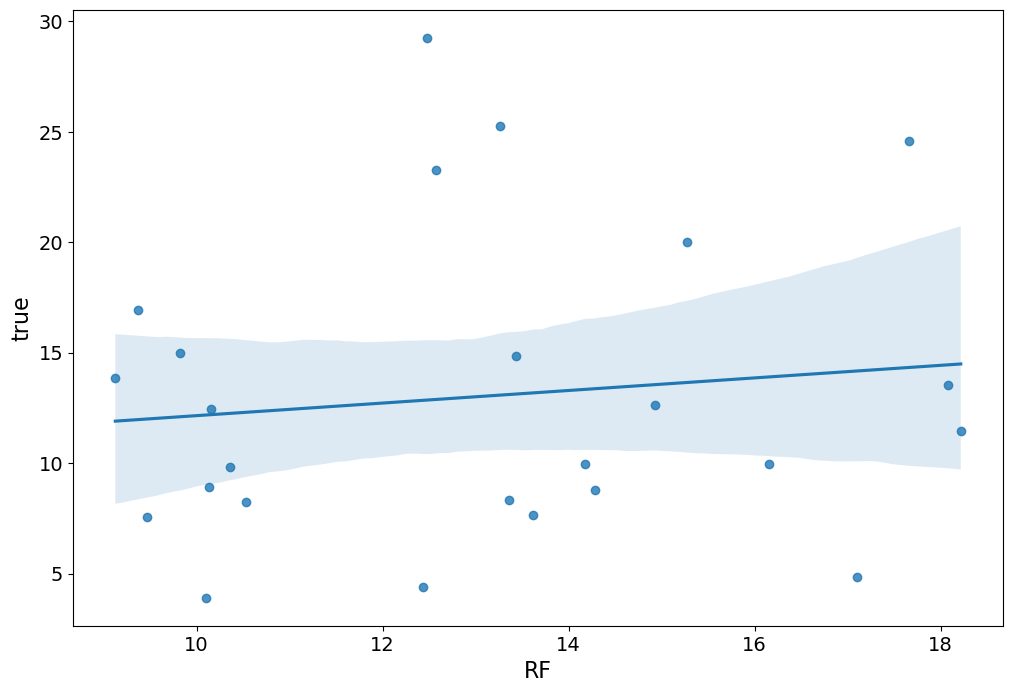

In [14]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [15]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'sAA_React')

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 

y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_saa_react",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope   0.086849 ±   0.035069
 2. spectrum_30            0.062297 ±   0.025874
 3. logRelF0-H1-H2_sma3nz_stddevNorm   0.060050 ±   0.021899
 4. mfcc3_sma3_amean       0.057869 ±   0.022516
 5. spectrum_32            0.055407 ±   0.023755



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 144.0 pvalue: 0.6338268518447876


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
52.169106402364896
Mean_Absolute_Error:
40.136190463168276
Standard Deviation of the Error:
33.32719427022848
Spearman Correlation:
Spearman r: 0.17811118 (p=0.39432287)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
54.183483586828984
Mean_Absolute_Error:
42.34357666666666
Standard Deviation of the abs Error:
33.806381182822406
Saved CSV: RF_saa_react_loo_abs_error.csv


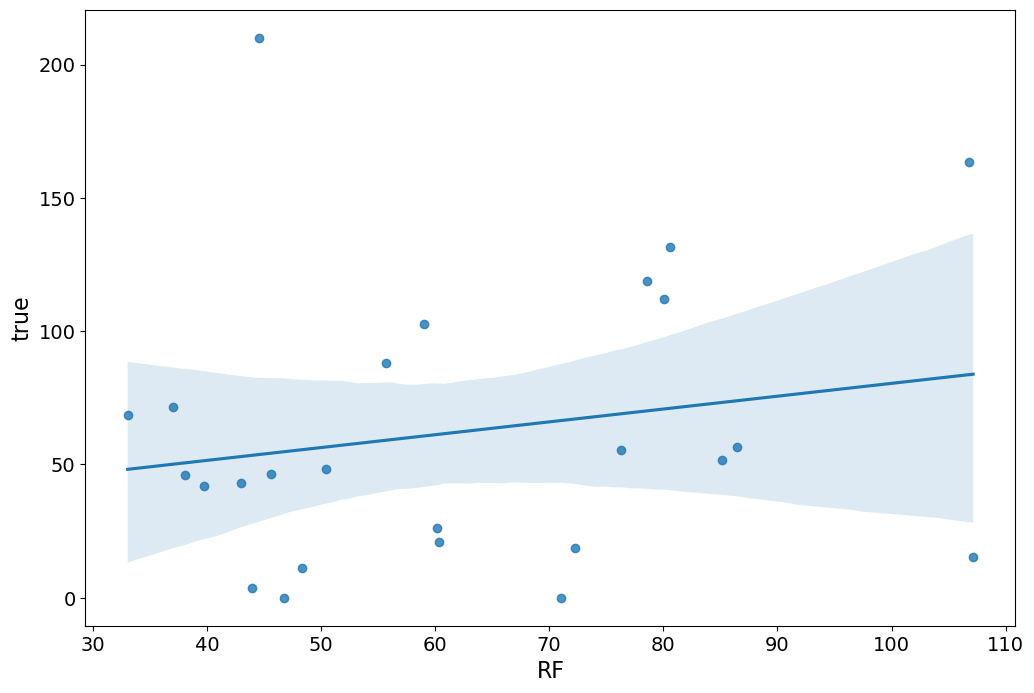

In [16]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [17]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'PANA_Delta_NA') 

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_pana_delta_na",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope   0.211869 ±   0.048615
 2. F1bandwidth_sma3nz_amean   0.051258 ±   0.016209
 3. mfcc1V_sma3nz_amean    0.050165 ±   0.021278
 4. hammarbergIndexUV_sma3nz_amean   0.038582 ±   0.013787
 5. stdevF0Hz              0.035937 ±   0.014056



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 110.0 pvalue: 0.16449612379074097


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
3.760731249292527
Mean_Absolute_Error:
2.814711510643639
Standard Deviation of the Error:
2.494092749128535
Spearman Correlation:
Spearman r: 0.53332047 (p=0.00604533)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
4.119314263321021
Mean_Absolute_Error:
3.2200000000000006
Standard Deviation of the abs Error:
2.5691146334875756
Saved CSV: RF_pana_delta_na_loo_abs_error.csv


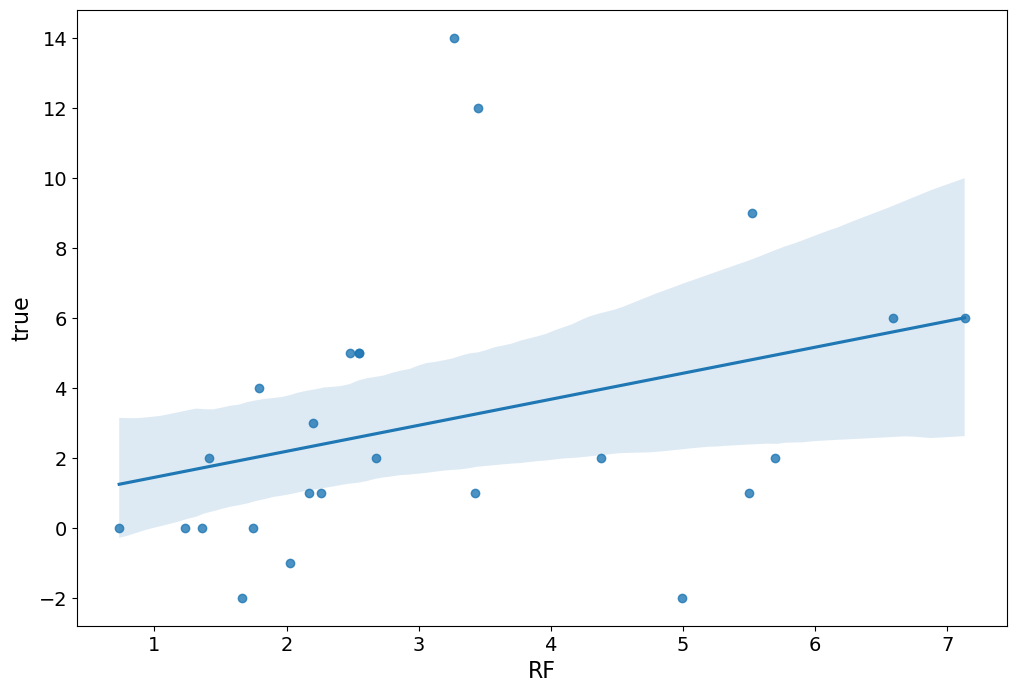

In [18]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

In [19]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'PANA_Delta_PA') 

space = dict()
space['max_depth'] = [2, 4, 5, 10]
model=RandomForestRegressor(n_estimators=1000) 
  
y_pred, y_true, z_test = myml.loo_regression(
    X=X,
    y=y,
    z=vpn,
    model=model,
    name="RF_pana_delta_pa",
    space=space,
    scaling="yes",
    features=audio
)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_9             0.093074 ±   0.029366
 2. logRelF0-H1-H2_sma3nz_amean   0.090128 ±   0.026740
 3. spectrum_16            0.051615 ±   0.018073
 4. logRelF0-H1-A3_sma3nz_stddevNorm   0.051312 ±   0.021904
 5. spectrum_7             0.036365 ±   0.016238



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 160.0 pvalue: 0.9578450322151184


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.278501633033218
Mean_Absolute_Error:
3.786753058069038
Standard Deviation of the Error:
3.6773741674106444
Spearman Correlation:
Spearman r: -0.05718763 (p=0.78599017)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
4.773334497206562
Mean_Absolute_Error:
3.7166666666666663
Standard Deviation of the abs Error:
2.9951813152313687
Saved CSV: RF_pana_delta_pa_loo_abs_error.csv


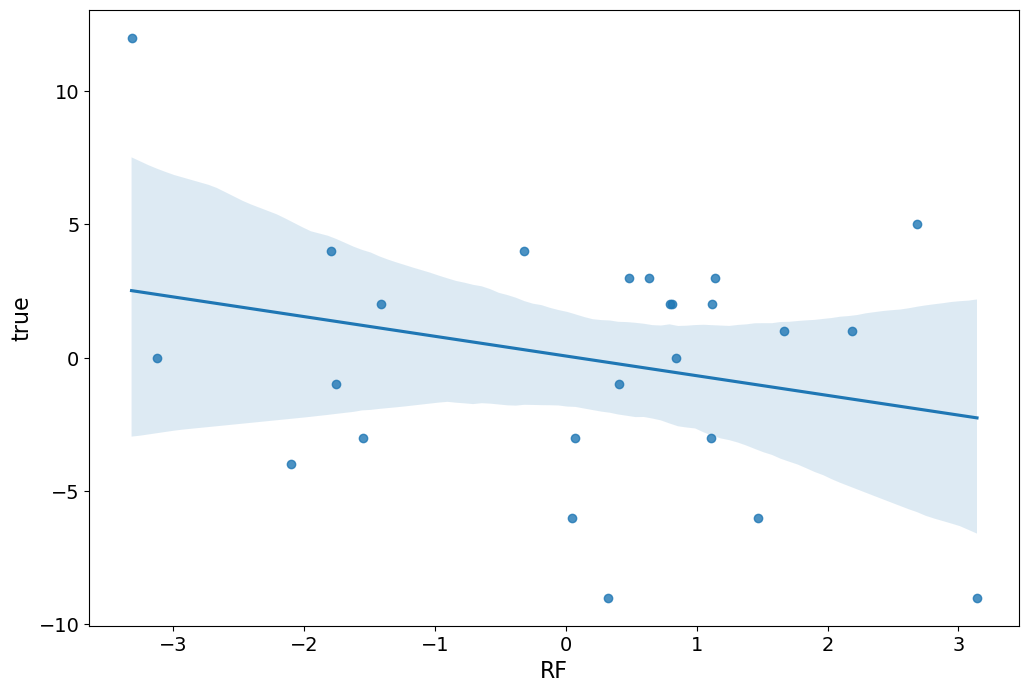

In [20]:
myml.reg_cor(y_pred, y_true, 'RF', 'true')

# Support Vector Machine

### with hyperparameter tuning (Kernel, Epsilon, C)

Here we are using a LOO (Leave One Out) for regression with a nested 5-fold CV for hyperparameter tuning (GridSearchCV).
In each iteraton the model is tuned on the training data and then predicts the hold out sample. Performance is compared to a mean-baseline and repeated for all folds.

This is done to predict Cortisol_React, cort_20_min, sAA_React, PANA_Delta_NA, PANA_Delta_PA

In [21]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'Cortisol_React') 

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_cortisol_react", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. F1bandwidth_sma3nz_amean   0.052825 ±   0.042166
 2. F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2   0.050596 ±   0.032484
 3. F2bandwidth_sma3nz_amean   0.036993 ±   0.032044
 4. logRelF0-H1-H2_sma3nz_stddevNorm   0.036554 ±   0.035277
 5. spectrum_33            0.034068 ±   0.022660



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 91.0 pvalue: 0.055070459842681885


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
6.415717892526578
Mean_Absolute_Error:
4.433633700517361
Standard Deviation of the Error:
4.637275955355946
Spearman Correlation:
Spearman r: 0.34417691 (p=0.09204647)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.704226466988215
Mean_Absolute_Error:
5.549382187866667
Standard Deviation of the abs Error:
3.7617828025622964
Saved CSV: SVR_cortisol_react_loo

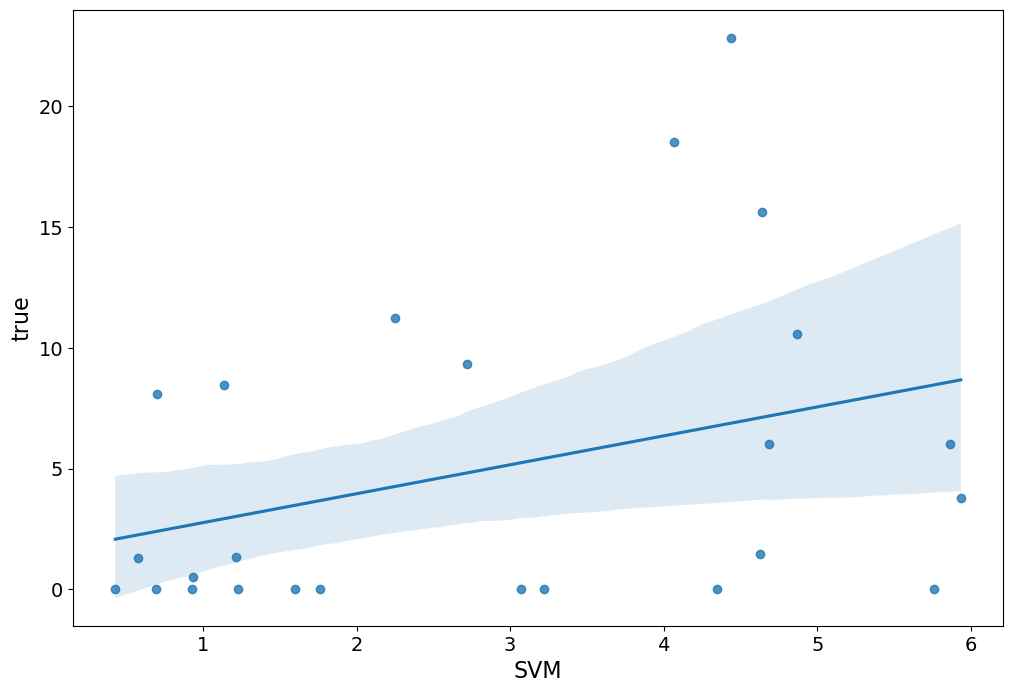

In [22]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [23]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'cort_20_min') 

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]


y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_cort_20_min", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. F1bandwidth_sma3nz_stddevNorm   0.116704 ±   0.141971
 2. F1bandwidth_sma3nz_amean   0.113456 ±   0.146925
 3. slopeUV500-1500_sma3nz_amean   0.112678 ±   0.145899
 4. spectrum_10            0.112092 ±   0.146511
 5. logRelF0-H1-H2_sma3nz_stddevNorm   0.112089 ±   0.115180



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 86.0 pvalue: 0.03933870792388916


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
7.524697268945059
Mean_Absolute_Error:
6.200374525515372
Standard Deviation of the Error:
4.263381842224464
Spearman Correlation:
Spearman r: -0.54087325 (p=0.00524290)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.965016033273538
Mean_Absolute_Error:
5.525627583333333
Standard Deviation of the abs Error:
4.240151902239267
Saved CSV: SVR_cort_20_min_loo_abs_error.

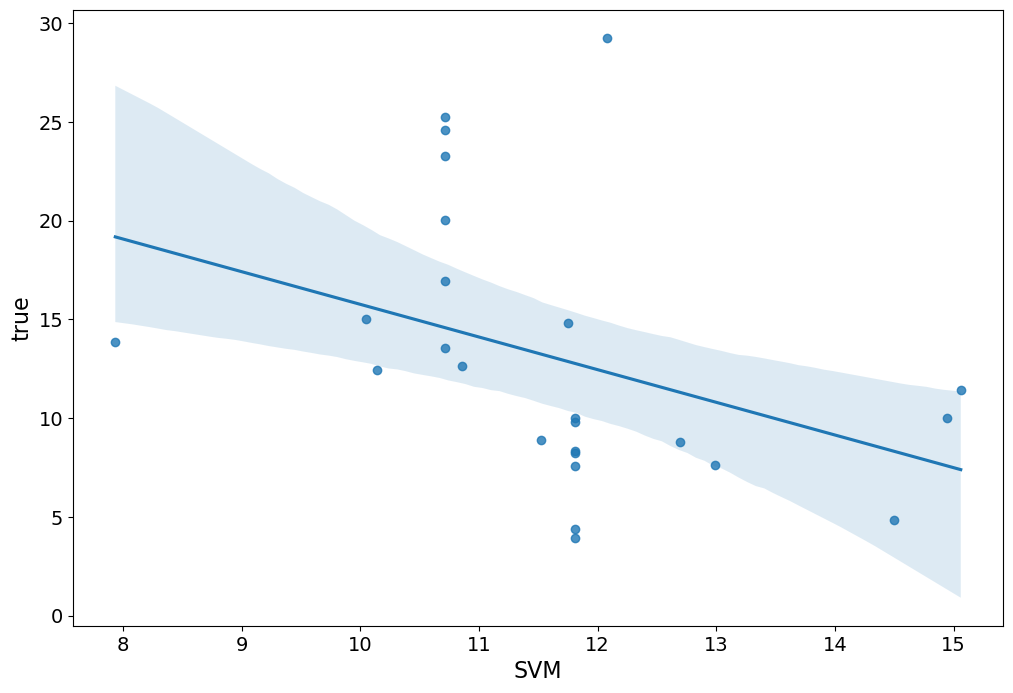

In [24]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [25]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'sAA_React') 

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_saa_react", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2   1.828965 ±   2.626228
 2. F0semitoneFrom27.5Hz_sma3nz_stddevNorm   1.766345 ±   2.707895
 3. logRelF0-H1-H2_sma3nz_amean   1.521343 ±   2.384621
 4. logRelF0-H1-H2_sma3nz_stddevNorm   1.465256 ±   2.196553
 5. mfcc1V_sma3nz_stddevNorm   1.277455 ±   2.243921



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 153.0 pvalue: 0.8119303584098816


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
57.27292226720497
Mean_Absolute_Error:
43.43444768484247
Standard Deviation of the Error:
37.33143955619693
Spearman Correlation:
Spearman r: 0.06885940 (p=0.74362345)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
54.183483586828984
Mean_Absolute_Error:
42.34357666666666
Standard Deviation of the abs Error:
33.806381182822406
Saved CSV: S

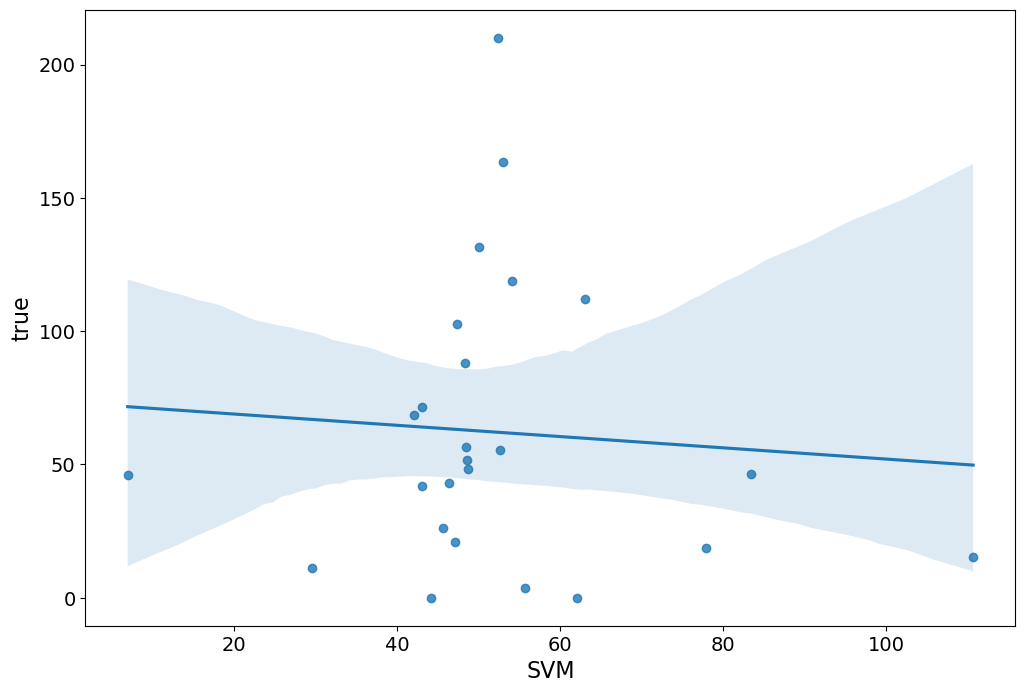

In [26]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [27]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'PANA_Delta_NA') 

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_pana_delta_na", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. spectrum_21            0.087114 ±   0.203345
 2. F2bandwidth_sma3nz_stddevNorm   0.079400 ±   0.151530
 3. alphaRatioUV_sma3nz_amean   0.076683 ±   0.154314
 4. spectrum_13            0.071770 ±   0.147694
 5. mfcc1V_sma3nz_amean    0.069910 ±   0.146908



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 155.0 pvalue: 0.8531995415687561


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
4.298942756476905
Mean_Absolute_Error:
3.449927375584853
Standard Deviation of the Error:
2.564938581458718
Spearman Correlation:
Spearman r: 0.10265585 (p=0.62534111)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
4.119314263321021
Mean_Absolute_Error:
3.2200000000000006
Standard Deviation of the abs Error:
2.5691146334875756
Saved CSV: SVR_pana_delta_na_loo_abs_error.csv


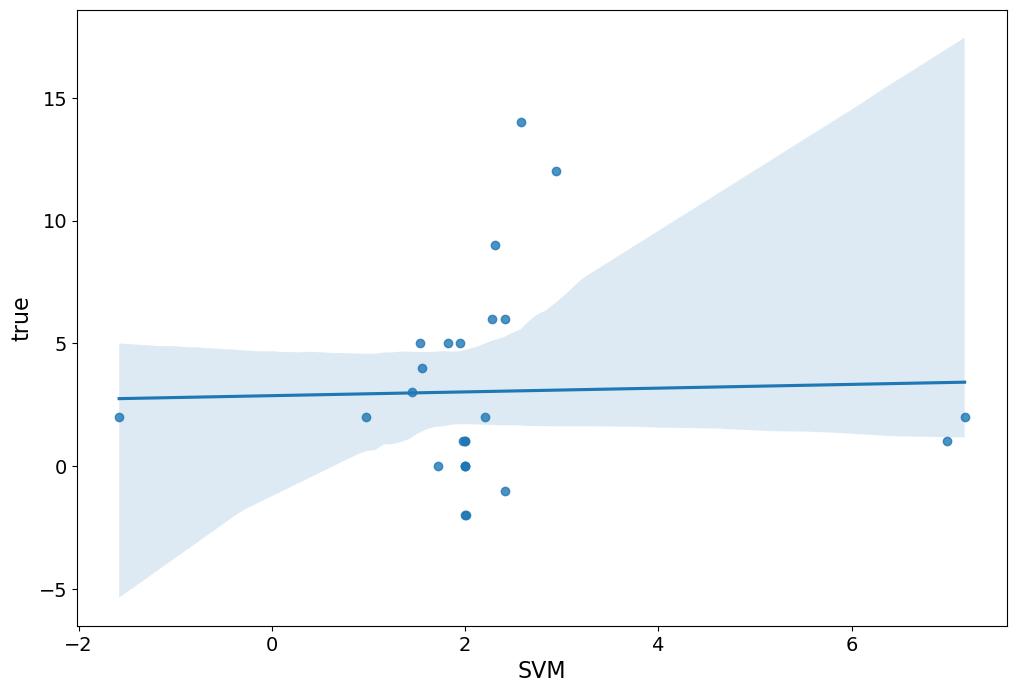

In [28]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

In [29]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'PANA_Delta_PA') 

model = SVR(kernel='rbf', gamma='scale')

space = dict()
space['C'] = [10, 1.0, 0.1, 0.01]
space['kernel'] = ['linear', 'rbf']
space['gamma'] = ['scale', 0.001, 0.01, 0.1, 1, 10]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "SVR_pana_delta_pa", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (Permutation Importance, gemittelt über alle Folds):
 1. spectrum_16            0.139475 ±   0.361817
 2. logRelF0-H1-A3_sma3nz_stddevNorm   0.137774 ±   0.399381
 3. stdevF0Hz              0.136636 ±   0.409543
 4. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope   0.135406 ±   0.395451
 5. F2frequency_sma3nz_stddevNorm   0.134390 ±   0.378335



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 136.0 pvalue: 0.49078595638275146


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.017175048713228
Mean_Absolute_Error:
3.9550312052792997
Standard Deviation of the Error:
3.087033144411888
Spearman Correlation:
Spearman r: -0.44618798 (p=0.02537288)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
4.773334497206562
Mean_Absolute_Error:
3.7166666666666663
Standard Deviation of the abs Error:
2.9951813152313687
Saved CSV: SVR_pana_delta_

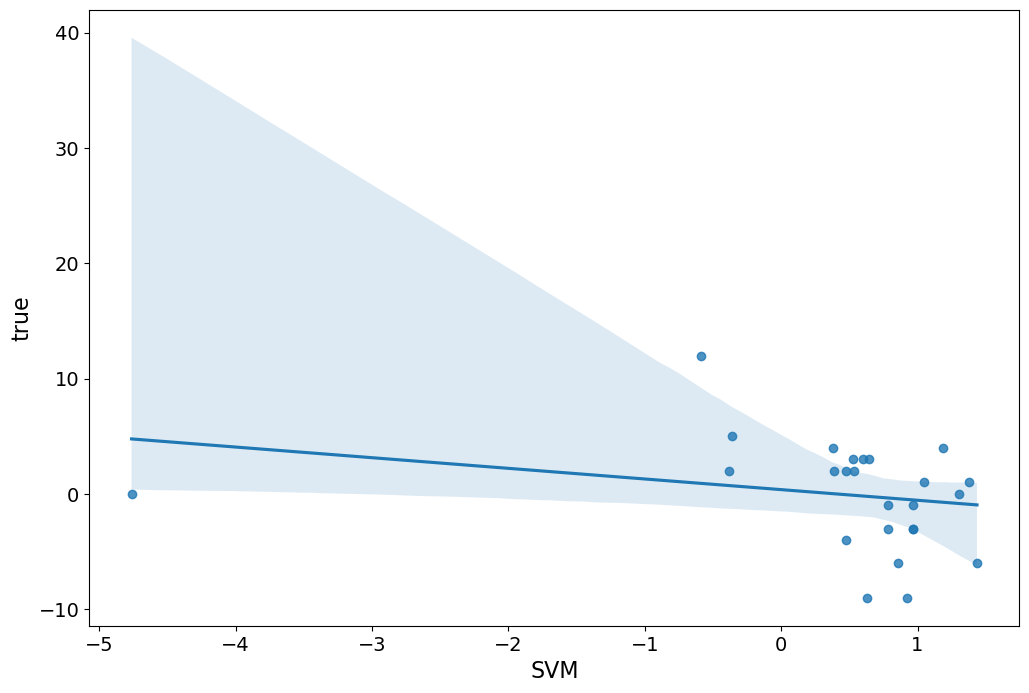

In [30]:
myml.reg_cor(y_pred, y_true, 'SVM', 'true')

# XGBoost

### with hyperparameter tuning (max_depth, learning_rate, n_estimators)

Here we are using a LOO (Leave One Out) for regression with a nested 5-fold CV for hyperparameter tuning (GridSearchCV).
In each iteraton the model is tuned on the training data and then predicts the hold out sample. Performance is compared to a mean-baseline and repeated for all folds.

This is done to predict Cortisol_React, cort_20_min, sAA_React, PANA_Delta_NA, PANA_Delta_PA

In [31]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'Cortisol_React')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_cortisol_react", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_36            0.171126 ±   0.117727
 2. F1bandwidth_sma3nz_amean   0.150048 ±   0.070939
 3. apq5Shimmer            0.097059 ±   0.078216
 4. apq3Shimmer            0.090735 ±   0.084718
 5. mfcc3_sma3_amean       0.073743 ±   0.062154



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 162.0 pvalue: 0.9892640758529487


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
7.159631081350053
Mean_Absolute_Error:
5.553187804961755
Standard Deviation of the Error:
4.5191174385999044
Spearman Correlation:
Spearman r: 0.06045633 (p=0.77405990)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.704226466988215
Mean_Absolute_Error:
5.549382187866667
Standard Deviation of the abs Error:
3.7617828025622964
Saved CSV: XGB_cortisol_react_loo_abs_error.csv


In [12]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'cort_20_min')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_cort_20_min", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. spectrum_3             0.273597 ±   0.102298
 2. spectrum_36            0.263423 ±   0.091780
 3. apq5Shimmer            0.083891 ±   0.064926
 4. mfcc3_sma3_stddevNorm   0.058977 ±   0.055271
 5. spectrum_25            0.054944 ±   0.050846



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 139.0 pvalue: 0.5424043536186218


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
7.091261904668444
Mean_Absolute_Error:
5.783062437010351
Standard Deviation of the Error:
4.103923031715121
Spearman Correlation:
Spearman r: -0.08155415 (p=0.69835572)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
6.965016033273538
Mean_Absolute_Error:
5.525627583333333
Standard Deviation of the abs Error:
4.240151902239267
Saved CSV: XGB_cort_20_min_loo_abs_error.csv


In [13]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'sAA_React')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_saa_react", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. mfcc3_sma3_amean       0.220399 ±   0.126908
 2. spectrum_30            0.190043 ±   0.087748
 3. logRelF0-H1-H2_sma3nz_stddevNorm   0.151597 ±   0.067807
 4. spectrum_33            0.075622 ±   0.066011
 5. mfcc1V_sma3nz_stddevNorm   0.063389 ±   0.047159



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 147.0 pvalue: 0.6915188431739807


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
62.66887653992731
Mean_Absolute_Error:
50.04937420043945
Standard Deviation of the Error:
37.71535799804952
Spearman Correlation:
Spearman r: 0.11502212 (p=0.58404234)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
54.183483586828984
Mean_Absolute_Error:
42.34357666666666
Standard Deviation of the abs Error:
33.806381182822406
Saved CSV: XGB_saa_react_loo_abs_error.csv


In [14]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'PANA_Delta_NA')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_pana_delta_na", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope   0.597478 ±   0.114362
 2. F1bandwidth_sma3nz_amean   0.097916 ±   0.041942
 3. hammarbergIndexUV_sma3nz_amean   0.050790 ±   0.041258
 4. alphaRatioUV_sma3nz_amean   0.041640 ±   0.026658
 5. stdevF0Hz              0.021414 ±   0.010144



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 65.0 pvalue: 0.007370948791503906


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
3.177148831365359
Mean_Absolute_Error:
2.082511647939682
Standard Deviation of the Error:
2.3994624258032924
Spearman Correlation:
Spearman r: 0.66577915 (p=0.00028072)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
4.119314263321021
Mean_Absolute_Error:
3.2200000000000006
Standard Deviation of the abs Error:
2.5691146334875756
Saved CSV: XGB_pana_delta_na_loo_abs_error.csv


In [12]:
X, y, vpn= myml.split_and_shuffle(df_TSST, audio, 'PANA_Delta_PA')

model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="rmse",
    n_jobs=-1
)

space = dict()
space["max_depth"] = [1, 2, 4, 8]
space["learning_rate"] = [0.03, 0.1, 0.2]
space["n_estimators"] = [50, 100, 150]

y_pred, y_true, z_test = myml.loo_regression(X, y, vpn, model, "XGB_pana_delta_pa", space, 'yes', audio)

Shape of X:
(25, 144)
Shape of y:
(25,)
Top 5 Features (gemittelt über alle Folds):
 1. F1frequency_sma3nz_stddevNorm   0.119739 ±   0.058698
 2. spectrum_0             0.102784 ±   0.046500
 3. spectrum_16            0.084971 ±   0.054494
 4. spectrum_9             0.079647 ±   0.069214
 5. spectrum_24            0.068194 ±   0.030247



Wilcoxon Signed Rank Test
---------------------------------
Statistic: 145.0 pvalue: 0.6528410911560059


Crossvalidierte Ergebnisse
---------------------------------
Root Mean Squared Error:
5.4496628098210795
Mean_Absolute_Error:
3.7389447259902955
Standard Deviation of the Error:
3.9647341747885623
Spearman Correlation:
Spearman r: -0.00772806 (p=0.97075413)




Baseline: Root Mean Squared Error
---------------------------------
Root Mean Squared Error:
4.773334497206562
Mean_Absolute_Error:
3.7166666666666663
Standard Deviation of the abs Error:
2.9951813152313687
Saved CSV: XGB_pana_delta_pa_loo_abs_error.csv
